# Homework


The homework is to prepare a report for the Ministry of Transport, revealing the nature and characteristics of flight delays. The report should help identify problem areas and contribute to decision-making. Therefore, strive not to state general facts, but to show problems. For example, the fact "the average departure delay is 15 minutes" by itself says little and does not help to understand why this is happening. On the contrary, a graph showing that on Mondays delays increase threefold compared to other days against the background of an increase in the number of flights and passengers suggests a possible cause of the problem: airports cannot cope with uneven load.

The report should be in the form of a notebook with a clear structure. At the beginning of the Markdown cell there is a brief description of the question under study (what we will study), then the code and all its outputs (tables, graphs, values), then again in the Markdown cell in which your brief conclusion is formulated.

The report should contain at least **5 results** confirmed by graphs. For variety of material, use different types of diagrams. All graphs should be provided with the necessary signatures (axis designations, title, color scheme legend).

To solve the problems, use the methods of the `pandas` library.


Неравномерная нагрузка на аэропорты в разные дни недели может приводить к росту задержек(и издержек). Посмотрим, как меняется средняя задержка вылета в зависимости от дня недели. Это позволит выявить дни, в которые пропускная способность инфраструктуры не справляется с объемом перевозок.

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_3340\2554749221.py:6: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv('flights.csv')


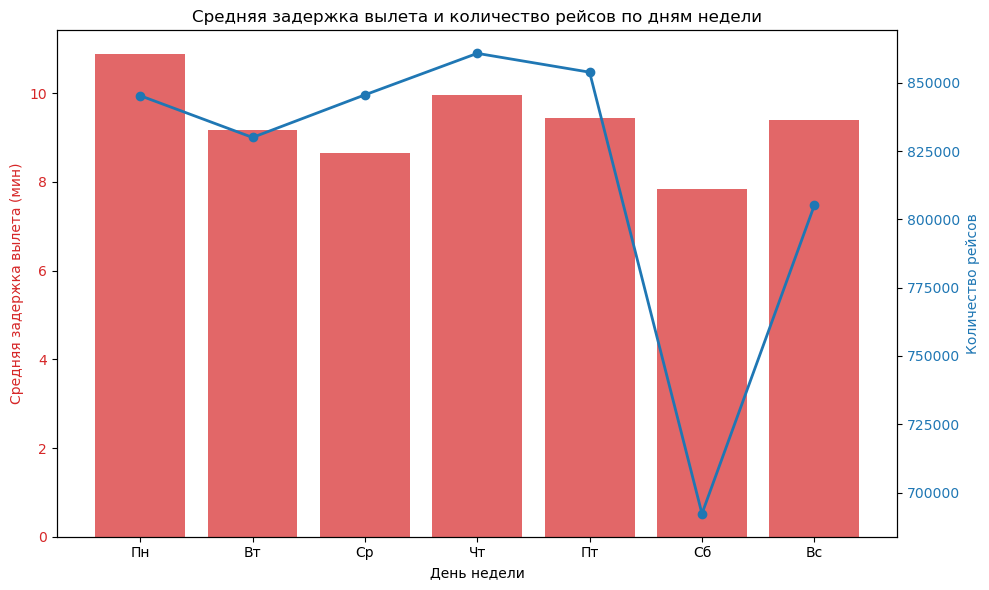

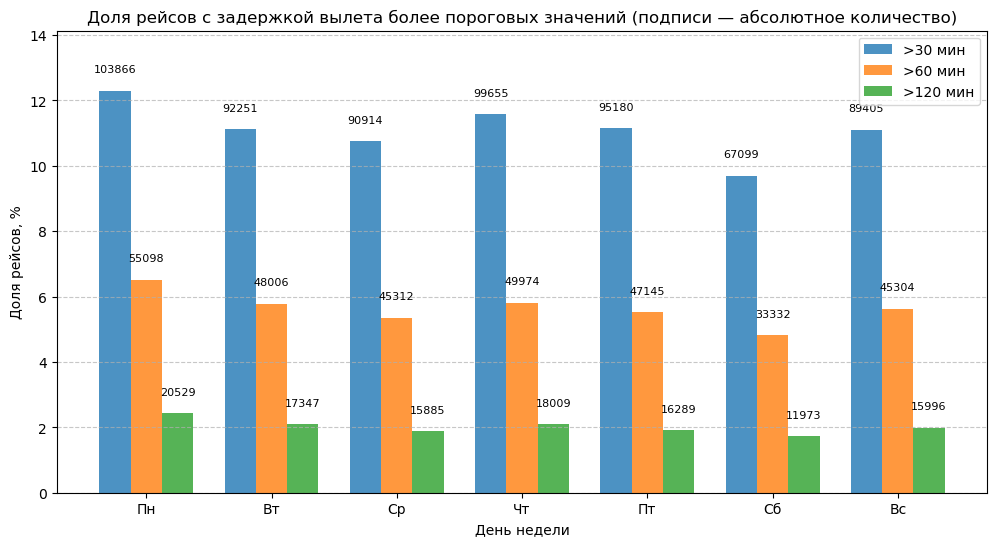

Абсолютное количество рейсов с задержкой более пороговых значений по дням недели:
DAY_LABEL  flight_count  delayed_30  delayed_60  delayed_120
       Пн        845288      103866       55098        20529
       Вт        829991       92251       48006        17347
       Ср        845583       90914       45312        15885
       Чт        860780       99655       49974        18009
       Пт        853884       95180       47145        16289
       Сб        692253       67099       33332        11973
       Вс        805147       89405       45304        15996


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
flights = pd.read_csv('flights.csv')

# Удалим строки, где нет информации о задержке вылета (отменённые или diverted рейсы)
flights = flights[flights['DEPARTURE_DELAY'].notna()]

# Преобразование дня недели в читаемый вид (1 = понедельник, 7 = воскресенье)
days_map = {1: 'Пн', 2: 'Вт', 3: 'Ср', 4: 'Чт', 5: 'Пт', 6: 'Сб', 7: 'Вс'}
flights['DAY_OF_WEEK_LABEL'] = flights['DAY_OF_WEEK'].map(days_map)

# Группировка по дню недели: средняя задержка и количество рейсов
delay_by_day = flights.groupby('DAY_OF_WEEK').agg(
    avg_departure_delay=('DEPARTURE_DELAY', 'mean'),
    flight_count=('FLIGHT_NUMBER', 'count')
).reset_index()
delay_by_day['DAY_LABEL'] = delay_by_day['DAY_OF_WEEK'].map(days_map)
delay_by_day = delay_by_day.sort_values('DAY_OF_WEEK')

# Расчёт долей и абсолютных чисел рейсов с задержкой более 30, 60, 120 минут
thresholds = [30, 60, 120]
for thr in thresholds:
    col_name = f'delayed_{thr}'
    # абсолютное значение
    delay_by_day[col_name] = flights.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].apply(
        lambda x: (x > thr).sum()
    ).values
    # проценты
    delay_by_day[f'pct_delay_{thr}'] = delay_by_day[col_name] / delay_by_day['flight_count'] * 100

# первый график (средняя задержка и количество рейсов)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('День недели')
ax1.set_ylabel('Средняя задержка вылета (мин)', color=color)
ax1.bar(delay_by_day['DAY_LABEL'], delay_by_day['avg_departure_delay'], color=color, alpha=0.7, label='Средняя задержка')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Количество рейсов', color=color)
ax2.plot(delay_by_day['DAY_LABEL'], delay_by_day['flight_count'], color=color, marker='o', linewidth=2, label='Количество рейсов')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Средняя задержка вылета и количество рейсов по дням недели')
fig.tight_layout()
plt.show()

# второй график (доля рейсов с задержкой больще порогов)
plt.figure(figsize=(12, 6))
x = np.arange(len(delay_by_day['DAY_LABEL']))
width = 0.25

bars30 = plt.bar(x - width, delay_by_day['pct_delay_30'], width, label='>30 мин', alpha=0.8)
bars60 = plt.bar(x, delay_by_day['pct_delay_60'], width, label='>60 мин', alpha=0.8)
bars120 = plt.bar(x + width, delay_by_day['pct_delay_120'], width, label='>120 мин', alpha=0.8)

# подписи с абсолютными значениями над столбцами
for bars, thr in zip([bars30, bars60, bars120], thresholds):
    for bar, day in zip(bars, delay_by_day['DAY_LABEL']):
        height = bar.get_height()
        abs_val = delay_by_day.loc[delay_by_day['DAY_LABEL'] == day, f'delayed_{thr}'].values[0]
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{abs_val}', ha='center', va='bottom', fontsize=8)

plt.xlabel('День недели')
plt.ylabel('Доля рейсов, %')
plt.title('Доля рейсов с задержкой вылета более пороговых значений (подписи — абсолютное количество)')
plt.xticks(x, delay_by_day['DAY_LABEL'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(delay_by_day['pct_delay_30'])*1.15)  #  место для подписей
plt.show()

print("Абсолютное количество рейсов с задержкой более пороговых значений по дням недели:")
print(delay_by_day[['DAY_LABEL', 'flight_count', 'delayed_30', 'delayed_60', 'delayed_120']].to_string(index=False))
plt.show()